# 3. Model training

In [2]:
%pip uninstall -y numpy albumentations opencv-python-headless opencv-python

%pip install "opencv-python-headless==4.9.0.80"

%pip install --no-deps -r requirements.txt

# %pip install albumentations
# %pip show albumentations


# in die requirements.txt packen?

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: albumentations 2.0.8
Uninstalling albumentations-2.0.8:
  Successfully uninstalled albumentations-2.0.8
Found existing installation: opencv-python-headless 4.9.0.80
Uninstalling opencv-python-headless-4.9.0.80:
  Successfully uninstalled opencv-python-headless-4.9.0.80
Note: you may need to restart the kernel to use updated packages.


You can safely remove it manually.
You can safely remove it manually.
You can safely remove it manually.


  Using cached opencv_python_headless-4.9.0.80-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached numpy-2.3.2-cp311-cp311-win_amd64.whl.metadata (60 kB)
Using cached opencv_python_headless-4.9.0.80-cp37-abi3-win_amd64.whl (38.5 MB)
Using cached numpy-2.3.2-cp311-cp311-win_amd64.whl (13.1 MB)

   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   --------------------------

### 3.1. Augmentation variant 1 | 

In [ ]:
from pathlib import Path
from torch.utils.data import DataLoader, Dataset, random_split
from skimage.io import imread, imsave
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2  # Used to convert to PyTorch tensors


import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="skimage")


preprocessed_train_images = Path('image_preprocessing') / 'preprocessed_data' / 'preprocessed_train_images'
preprocessed_train_masks  = Path('image_preprocessing') / 'preprocessed_data' / 'preprocessed_train_masks'

preprocessed_test_images  = Path('image_preprocessing') / 'preprocessed_data' / 'preprocessed_test_images'
preprocessed_test_masks   = Path('image_preprocessing') / 'preprocessed_data' / 'preprocessed_test_masks'


class SegmentationDataset(Dataset):
    def __init__(self, img_dir, mask_dir=None, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        # Properly extract image_ids by removing suffixes like '_image', '_enhanced', '_pp'
        self.image_ids = sorted([file.stem.replace('_image', '').replace('_enhanced', '').replace('_pp', '')
                                 for file in img_dir.iterdir() if file.suffix == '.png'])
        
    
    def __len__(self):
        return len(self.image_ids)
    

    def __getitem__(self, index):
        image_id = self.image_ids[index]

        # Attempt to load the image
        img_path = self.img_dir / f'{image_id}.png'
        if not img_path.exists():
            img_path = self.img_dir / f'{image_id}_pp_enhanced.png'

        if not img_path.exists():
            raise FileNotFoundError(f'Image not found for {image_id} at {img_path}')

        image = imread(img_path).astype(np.float32) / 255.0  # Normalize image

        if self.mask_dir:
            # Correct mask path generation to include '_mask.png'
            mask_path = self.mask_dir / f'{image_id}_mask.png'

            if not mask_path.exists():
                raise FileNotFoundError(f'Mask not found for {image_id} at {mask_path}')

            mask = imread(mask_path).astype(np.float32) / 255.0  # Normalize mask

            # Ensure mask has shape [H, W] for binary segmentation
            if len(mask.shape) == 2:  # If mask is [H, W], add a channel dimension
                mask = np.expand_dims(mask, axis=2)  # Convert to [H, W, 1]

            if self.transform:
                augmented = self.transform(image=image, mask=mask)
                image = augmented['image']
                mask = augmented['mask']

            return image, mask
        else:
            if self.transform:
                augmented = self.transform(image=image)
                image = augmented['image']
            return image


# Define augmentations using Albumentations
train_transform = A.Compose([
    A.RandomRotate90(),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    # A.ElasticTransform()
    # A.GridDistortion()
    A.GaussianBlur(p=0.2),
    A.Resize(256, 256),
    ToTensorV2()
])

"""
# Define augmentations using Albumentations
train_transform = A.Compose([
    A.RandomRotate90(),  # Randomly rotate the image 90 degrees
    A.HorizontalFlip(p=0.5),  # Random horizontal flip
    A.VerticalFlip(p=0.5),    # Random vertical flip
    A.RandomBrightnessContrast(p=0.2),  # Random brightness and contrast adjustments
    A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.3),  # Elastic deformation
    A.GridDistortion(p=0.3),  # Distorts the image grid
    A.Resize(224, 224),  # Resize the image to 224x224
    ToTensorV2()  # Converts to PyTorch tensors
])
"""

val_transform = A.Compose([
    A.Resize(256, 256),
    ToTensorV2()
])

"""
val_transform = A.Compose([
    A.Resize(224, 224),  # Resize validation images to 224x224
    ToTensorV2()  # Converts to PyTorch tensors
])
"""

# Define datasets with transformations
train_dataset = SegmentationDataset(img_dir=preprocessed_train_images, mask_dir=preprocessed_train_masks, transform=train_transform)
test_dataset = SegmentationDataset(preprocessed_test_images, transform=val_transform)

# Split the dataset into training (80%) and validation (20%) sets
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])                                          # why have to chose at the image preprocessing stage between train and test, if we do a random_split here?

# Create data loaders
train_loader = DataLoader(train_subset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)


# Print number of images in train, validation, and test sets
print(f'Number of training images: \t{train_size}')
print(f'Number of validation images: \t{val_size}')
print(f'Number of test images: \t\t{len(test_dataset)}')

c:\Users\Leon\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of training images: 	450
Number of validation images: 	50
Number of test images: 		200


### 3.2. Augmentation variant 2 | 

In [ ]:
# Define a custom dataset class to load the images and masks
class SegmentationDataset(Dataset):
    def __init__(self, img_dir, mask_dir=None, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        # Properly extract image_ids by removing suffixes like '_image', '_enhanced', '_pp'
        self.image_ids = sorted([file.stem.replace('_image', '').replace('_enhanced', '').replace('_pp', '')
                                 for file in img_dir.iterdir() if file.suffix == '.png'])

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]

        # Attempt to load the image
        img_path = self.img_dir / f'{image_id}.png'
        if not img_path.exists():
            img_path = self.img_dir / f'{image_id}_pp_enhanced.png'

        if not img_path.exists():
            raise FileNotFoundError(f'Image not found for {image_id} at {img_path}')

        image = imread(img_path).astype(np.float32) / 255.0  # Normalize image

        if self.mask_dir:
            mask_path = self.mask_dir / f'{image_id}_mask.png'

            if not mask_path.exists():
                raise FileNotFoundError(f'Mask not found for {image_id} at {mask_path}')

            mask = imread(mask_path).astype(np.float32) / 255.0  # Normalize mask

            # Ensure both mask and image are resized to [H, W, 1]
            if len(mask.shape) == 2:  # If mask is [H, W], add a channel dimension
                mask = np.expand_dims(mask, axis=2)  # Convert to [H, W, 1]

            if self.transform:
                augmented = self.transform(image=image, mask=mask)
                image = augmented['image']
                mask = augmented['mask']

                # Ensure mask is [1, H, W] after transformation (transpose if necessary)
                if mask.ndim == 3 and mask.shape[-1] == 1:
                    mask = np.transpose(mask, (2, 0, 1))  # Convert to [1, H, W]

            return image, mask
        else:
            if self.transform:
                augmented = self.transform(image=image)
                image = augmented['image']
            return image
        

train_transform = A.Compose([
    A.RandomRotate90(),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    # A.ElasticTransform()
    # A.GridDistortion()
    A.GaussianBlur(p=0.2),
    A.Resize(256, 256),
    ToTensorV2()
])


val_transform = A.Compose([
    A.Resize(256, 256),
    ToTensorV2()
])


# Define datasets with transformations
train_dataset = SegmentationDataset(img_dir=preprocessed_train_images, mask_dir=preprocessed_train_masks, transform=train_transform)
test_dataset = SegmentationDataset(preprocessed_test_images, transform=val_transform)

# Split the dataset into training (90%) and validation (10%) sets
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

# Create data loaders
train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Check if loading is correct for the training set
for images, masks in train_loader:
    # DEBUGGING: Check shape of images and masks
    print(f'Train Batch - Images Shape: \t\t{images.shape} \tMasks Shape: {masks.shape}')
    break

# Check if loading is correct for the validation set
for images, masks in val_loader:
    # DEBUGGING: Check shape of images and masks
    print(f'Validation Batch - Images Shape: \t{images.shape} \tMasks Shape: {masks.shape}')
    break

Train Batch - Images Shape: 		torch.Size([16, 3, 256, 256]) 	Masks Shape: torch.Size([16, 1, 256, 256])
Validation Batch - Images Shape: 	torch.Size([16, 3, 256, 256]) 	Masks Shape: torch.Size([16, 1, 256, 256])


# 3.3. No Augmentation and batch size reduced from 16 to 8 | 

In [5]:
import torch
from torchvision import transforms


# Define a custom dataset class to load the images and masks
class SegmentationDataset(Dataset):
    def __init__(self, img_dir, mask_dir=None, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        # Properly extract image_ids by removing suffixes like '_image', '_enhanced', '_pp'
        self.image_ids = sorted([file.stem.replace('_image', '').replace('_enhanced', '').replace('_pp', '')
                                 for file in img_dir.iterdir() if file.suffix == '.png'])

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]

        # Attempt to load the image
        img_path = self.img_dir / f'{image_id}.png'
        #print(f"Trying to load image from: {img_path}")  # Debug statement
        if not img_path.exists():
            img_path = self.img_dir / f'{image_id}_pp_enhanced.png'
            #print(f"Trying alternative path: {img_path}")  # Debug statement

        if not img_path.exists():
            raise FileNotFoundError(f'Image not found for {image_id} at {img_path}')

        #print(f"Successfully loaded image: {img_path}")  # Debug statement
        image = imread(img_path).astype(np.float32) / 255.0  # Normalize image

        # Ensure image is in the format [C, H, W] (channels, height, width)
        if image.shape[-1] == 3:  # If the image is in [H, W, C] format
            image = np.transpose(image, (2, 0, 1))  # Convert to [C, H, W]

        if self.mask_dir:
            # Correct mask path generation to include '_mask.png'
            mask_path = self.mask_dir / f'{image_id}_mask.png'

            # Print the image ID and the mask path for debugging
            #print(f"Image ID: {image_id}, Mask Path: {mask_path}")

            if not mask_path.exists():
                raise FileNotFoundError(f"Mask not found for {image_id} at {mask_path}")

            #print(f"Successfully loaded mask: {mask_path}")  # Debug statement
            mask = imread(mask_path).astype(np.float32) / 255.0  # Normalize mask

            # Ensure mask has shape [1, H, W] for binary segmentation
            if len(mask.shape) == 2:  # If mask is [H, W], add a channel dimension
                mask = np.expand_dims(mask, axis=0)  # Convert to [1, H, W]

            # Apply transformations (if any)
            if self.transform:
                image = torch.tensor(image, dtype=torch.float32)  # Ensure image is float32
                mask = torch.tensor(mask, dtype=torch.float32)    # Ensure mask is float32

            return image, mask
        else:
            if self.transform:
                image = torch.tensor(image, dtype=torch.float32)  # Ensure image is float32
            return image

# Define transformations (if needed)
train_transform = transforms.Compose([
    transforms.ToTensor(),  # Convert image to tensor
])

val_transform = transforms.Compose([
    transforms.ToTensor(),  # Convert image to tensor
])

# Define datasets
train_dataset = SegmentationDataset(img_dir=preprocessed_train_images, mask_dir=preprocessed_train_masks, transform=train_transform)
test_dataset = SegmentationDataset(preprocessed_test_images)

# Split the dataset into training (80%) and validation (20%) sets
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

# Create data loaders
train_loader = DataLoader(train_subset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

# Check if loading is correct for the training set
for images, masks in train_loader:
    #print(f"Train Batch - Images Shape: {images.shape}, Masks Shape: {masks.shape}")
    break

# Check if loading is correct for the validation set
for images, masks in val_loader:
    #print(f"Validation Batch - Images Shape: {images.shape}, Masks Shape: {masks.shape}")
    break

# Check if loading is correct for the test set (without masks)
for images in test_loader:
    #print(f"Test Batch - Images Shape: {images.shape}")
    break


# Print number of images in train, validation, and test sets
print(f'Number of training images: \t{train_size}')
print(f'Number of validation images: \t{val_size}')
print(f'Number of test images: \t\t{len(test_dataset)}')

Number of training images: 	450
Number of validation images: 	50
Number of test images: 		200


### 3.4. Unet++ with NO attention | 

In [6]:
import torch.nn as nn
import torch.nn.functional as F


# Define U-Net++ model architecture
class UNetPlusPlus(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UNetPlusPlus, self).__init__()

        # Encoder path
        self.encoder1 = self.double_conv(in_channels, 64)
        self.encoder2 = self.double_conv(64, 128)
        self.encoder3 = self.double_conv(128, 256)
        self.encoder4 = self.double_conv(256, 512)

        # Bottleneck
        self.bottleneck = self.double_conv(512, 1024)

        # Decoder path with nested convolutions (UNet++)
        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.decoder4_1 = self.double_conv(1024, 512)
        self.decoder4_2 = self.double_conv(1024, 512)

        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.decoder3_1 = self.double_conv(512, 256)
        self.decoder3_2 = self.double_conv(512, 256)
        self.decoder3_3 = self.double_conv(512, 256)

        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.decoder2_1 = self.double_conv(256, 128)
        self.decoder2_2 = self.double_conv(256, 128)
        self.decoder2_3 = self.double_conv(256, 128)
        self.decoder2_4 = self.double_conv(256, 128)

        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.decoder1_1 = self.double_conv(128, 64)
        self.decoder1_2 = self.double_conv(128, 64)
        self.decoder1_3 = self.double_conv(128, 64)
        self.decoder1_4 = self.double_conv(128, 64)
        self.decoder1_5 = self.double_conv(128, 64)

        # Output layer
        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def double_conv(self, in_channels, out_channels, dropout_prob=0.1):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ELU(inplace=True),  # Switch to ELU activation
            nn.Dropout(dropout_prob),  # Add dropout
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ELU(inplace=True),  # Switch to ELU activation
        )

    def forward(self, x):
        # Encoder path
        e1 = self.encoder1(x)
        e2 = self.encoder2(F.max_pool2d(e1, 2))
        e3 = self.encoder3(F.max_pool2d(e2, 2))
        e4 = self.encoder4(F.max_pool2d(e3, 2))

        # Bottleneck
        b = self.bottleneck(F.max_pool2d(e4, 2))

        # Decoder path with nested convolutions (UNet++)
        d4_1 = self.upconv4(b)
        d4_1 = torch.cat([d4_1, e4], dim=1)
        d4_1 = self.decoder4_1(d4_1)

        d3_1 = self.upconv3(d4_1)
        d3_1 = torch.cat([d3_1, e3], dim=1)
        d3_1 = self.decoder3_1(d3_1)

        d2_1 = self.upconv2(d3_1)
        d2_1 = torch.cat([d2_1, e2], dim=1)
        d2_1 = self.decoder2_1(d2_1)

        d1_1 = self.upconv1(d2_1)
        d1_1 = torch.cat([d1_1, e1], dim=1)
        d1_1 = self.decoder1_1(d1_1)

        # Output
        out = torch.sigmoid(self.out_conv(d1_1))  # Use sigmoid for binary segmentation
        # Resize output to match the size of the input masks
        out = F.interpolate(out, size=(x.size(2), x.size(3)), mode='bilinear', align_corners=False)
        return out




# 4. Training and Validation

### 4.1. Training and Validation Unet++ NO attention | 

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

results = Path('results')
saved_models = results / 'saved_models'
Path(saved_models).mkdir(parents=True, exist_ok=True)



# Initialize weights using He initialization
def init_weights(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')

# Instantiate the U-Net++ model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNetPlusPlus(in_channels=3, out_channels=1).to(device)
model.to(device)

model.apply(init_weights)

# Focal Loss for class imbalance
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE_loss = nn.BCEWithLogitsLoss()(inputs, targets)
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss
        return F_loss


# Dice coefficient function
def dice_coefficient(preds, masks, smooth=1):
    preds = torch.sigmoid(preds) > 0.5  # Threshold predictions at 0.5
    preds = preds.float()
    masks = masks.float()
    intersection = (preds * masks).sum(dim=[1, 2])
    dice = (2. * intersection + smooth) / (preds.sum(dim=[1, 2]) + masks.sum(dim=[1, 2]) + smooth)
    return dice.mean()

# Dice loss
def dice_loss(preds, masks, smooth=1):
    intersection = (preds * masks).sum()
    dice = (2. * intersection + smooth) / (preds.sum() + masks.sum() + smooth)
    return 1 - dice

# Combined BCE and Dice loss with Focal Loss
def combined_loss(preds, masks, bce_weight=0.3):
    bce = FocalLoss()(preds, masks)
    dice = dice_loss(torch.sigmoid(preds), masks)
    return bce * bce_weight + dice * (1 - bce_weight)


# Define optimizer with weight decay (L2 regularization)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)  # Weight decay added                      # hier # lr=1e-4, weight_decay=1e-5
#scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5, verbose=True)
# gives better results                                                                                                  # Hyperparameter
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-3, steps_per_epoch=len(train_loader), epochs=500)  # max_lr=1e-3


# Early stopping parameters
patience = 50
best_val_loss = float('inf')
best_train_dice = float('-inf')  # Initialize for best training dice score
patience_counter = 0

# Store losses and metrics for visualization
train_losses = []
val_losses = []
train_dice_scores = []
val_dice_scores = []


# Training loop
epochs = 500 # hier

loss_list = []
val_loss_list = []

for epoch in range(epochs):
    model.train()
    train_loss = 0
    train_dice = 0
    num_train_samples = 0  # Initialize for normalizing across all examples
    for images, masks in train_loader:
        images = images.to(device).float()
        masks = masks.to(device).float()

        # Forward pass
        outputs = model(images)
        loss = combined_loss(outputs, masks)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Track the number of examples
        batch_size = images.size(0)
        num_train_samples += batch_size

        # Accumulate loss and dice score
        train_loss += loss.item() * batch_size  # Multiply by batch size for proper normalization
        train_dice += dice_coefficient(outputs, masks).item() * batch_size

    loss_list.append(train_loss) # hier

    # Validation loop
    model.eval()
    val_loss = 0
    val_dice = 0
    num_val_samples = 0  # Initialize for normalizing across all validation examples
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device).float()
            masks = masks.to(device).float()
            outputs = model(images)
            batch_size = images.size(0)
            num_val_samples += batch_size

            val_loss += combined_loss(outputs, masks).item() * batch_size  # Multiply by batch size
            val_dice += dice_coefficient(outputs, masks).item() * batch_size

    val_loss_list.append(val_loss) # hier

    # Average loss and dice score per epoch normalized by the number of samples
    train_loss /= num_train_samples  # Normalize over total number of training examples
    val_loss /= num_val_samples  # Normalize over total number of validation examples
    train_dice /= num_train_samples
    val_dice /= num_val_samples

    # Store losses and dice scores for visualization
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_dice_scores.append(train_dice)
    val_dice_scores.append(val_dice)

    print(f'Epoch [{epoch+1}/{epochs}]:'.ljust(16), 
          f'Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
          f'Train Dice: {train_dice:.4f}, Val Dice: {val_dice:.4f}')

    # Early stopping based on training dice
    if train_dice > best_train_dice:
        best_train_dice = train_dice
        torch.save(model.state_dict(), saved_models / 'unet++_224_model_500epochs_augmentations.pth')                   # § hier Name vlt ändern
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print('Early stopping triggered based on training dice!')
        break

    # Step scheduler
    scheduler.step(val_loss)



Epoch [1/500]:   Train Loss: 0.5478, Val Loss: 0.5426, Train Dice: 0.3229, Val Dice: 0.3113
Epoch [2/500]:   Train Loss: 0.5263, Val Loss: 0.5270, Train Dice: 0.3229, Val Dice: 0.3113
Epoch [3/500]:   Train Loss: 0.5169, Val Loss: 0.5208, Train Dice: 0.3229, Val Dice: 0.3113
Epoch [4/500]:   Train Loss: 0.5125, Val Loss: 0.5158, Train Dice: 0.3229, Val Dice: 0.3113
Epoch [5/500]:   Train Loss: 0.5098, Val Loss: 0.5183, Train Dice: 0.3229, Val Dice: 0.3113
Epoch [6/500]:   Train Loss: 0.5063, Val Loss: 0.5220, Train Dice: 0.3229, Val Dice: 0.3113
Epoch [7/500]:   Train Loss: 0.5049, Val Loss: 0.5176, Train Dice: 0.3229, Val Dice: 0.3113
Epoch [8/500]:   Train Loss: 0.5054, Val Loss: 0.5215, Train Dice: 0.3229, Val Dice: 0.3116
Epoch [9/500]:   Train Loss: 0.5028, Val Loss: 0.5197, Train Dice: 0.3230, Val Dice: 0.3119
Epoch [10/500]:  Train Loss: 0.5033, Val Loss: 0.5166, Train Dice: 0.3231, Val Dice: 0.3128
Epoch [11/500]:  Train Loss: 0.5042, Val Loss: 0.5190, Train Dice: 0.3230, Val D

'\noptimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)\nscheduler = ReduceLROnPlateau(optimizer, mode=\'min\', factor=0.5, patience=5, verbose=True)\n\n# Early stopping\npatience = 50\nbest_val_dice = float(\'-inf\')\npatience_counter = 0\n\n# Training loop\nepochs = 500 # hier\n\n\n# Store losses and metrics for visualization\ntrain_losses = []\nval_losses = []\ntrain_dice_scores = []\nval_dice_scores = []\n\n\n\nfor epoch in range(epochs):\n    model.train()\n    train_loss, train_dice, n_train = 0, 0, 0\n\n    for images, masks in train_loader:\n        images, masks = images.to(device).float(), masks.to(device).float()\n        outputs = model(images)\n        loss = criterion(outputs, masks)   # <<<<< hier criterion nutzen\n\n        optimizer.zero_grad()\n        loss.backward()\n        optimizer.step()\n\n        bs = images.size(0)\n        n_train += bs\n        train_loss += loss.item() * bs\n        train_dice += dice_coefficient(outputs, masks).item() * bs\n\

##### 4.1.1. Plot training and validation data

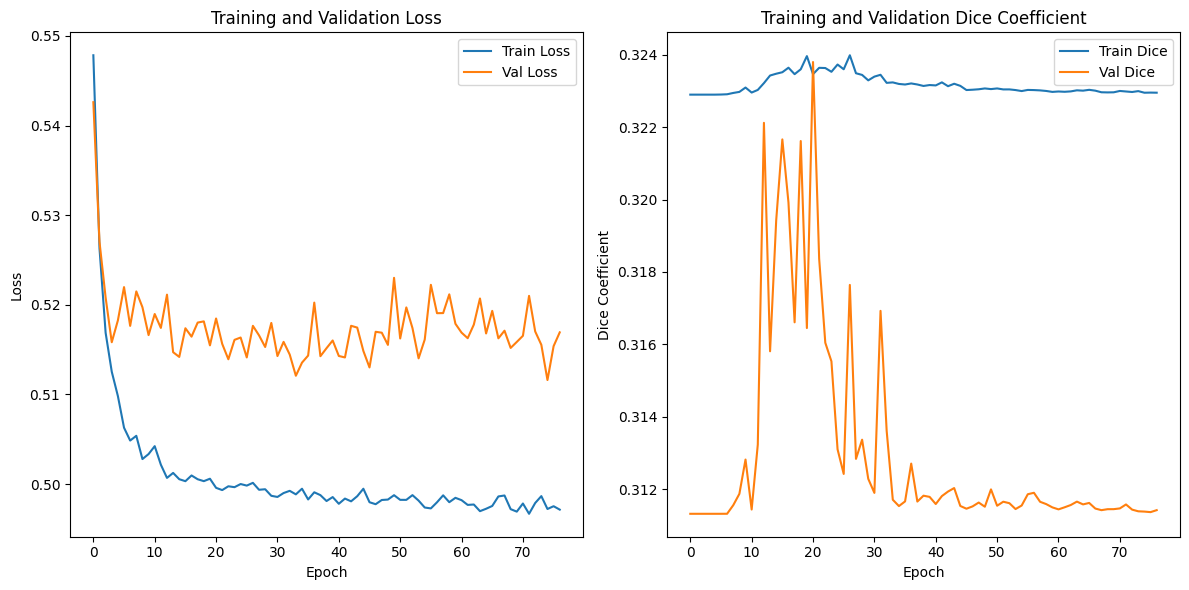

In [8]:
import matplotlib.pyplot as plt


# Plot losses and dice scores
plt.figure(figsize=(12, 6))

# Plot losses
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Plot dice scores
plt.subplot(1, 2, 2)
plt.plot(train_dice_scores, label='Train Dice')
plt.plot(val_dice_scores, label='Val Dice')
plt.xlabel('Epoch')
plt.ylabel('Dice Coefficient')
plt.title('Training and Validation Dice Coefficient')
plt.legend()

plt.tight_layout()
plt.show()

### 4.2. Evaluation Metrics | 

In [9]:
# Set your test paths
predicted_masks = results / 'predicted_masks'  # Directory to save predicted masks as pngs
model_path = saved_models / 'unet++_224_model_500epochs_augmentations.pth'

Path(predicted_masks).mkdir(parents=True, exist_ok=True)

model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()


# Custom dataset for test images
class TestDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        # Extract image IDs by removing '_pp_enhanced.png' from each filename
        self.image_ids = sorted([file.name.replace('_pp_enhanced.png', '') for file in img_dir.iterdir() if file.name.endswith('_pp_enhanced.png')])
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        img_path = self.img_dir / f'{image_id}_pp_enhanced.png'
        print(f'Loading image: {img_path}')  # Debugging: Confirm the correct image path
        image = imread(img_path).astype(np.float32) / 255.0  # Normalize to [0, 1]

        if self.transform:
            image = self.transform(image)

        return image, image_id

# Define a transformation for the test data
test_transform = transforms.Compose([
    transforms.ToTensor(),  # Converts numpy array to tensor
    transforms.ConvertImageDtype(torch.float32)  # Ensures the image is in float32
])

# DataLoader for test data
test_dataset = TestDataset(preprocessed_test_images, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# Function to calculate Dice coefficient
def dice_coefficient(pred_mask, gt_mask, smooth=1):
    # Ensure the masks are binary (0 or 1)
    pred_mask = (pred_mask > 0.5).astype(np.uint8)  # Threshold the predicted mask
    gt_mask = (gt_mask > 0.5).astype(np.uint8)      # Ensure ground truth mask is binary

    # Calculate intersection and Dice score
    intersection = np.sum(pred_mask * gt_mask)
    return (2. * intersection + smooth) / (np.sum(pred_mask) + np.sum(gt_mask) + smooth)

# Initialize an empty list to store Dice scores
dice_scores = []

# In the prediction loop, after resizing the predicted mask:
for images, image_ids in test_loader:
    images = images.to(device)

    # Make prediction
    with torch.no_grad():
        outputs = model(images)
        predicted_mask = torch.sigmoid(outputs).squeeze().cpu().numpy()

        # Ensure predicted mask is binary
        predicted_mask = (predicted_mask > 0.5).astype(np.uint8)  # Threshold to binary

    image_id = image_ids[0]
    print(f'Processing image ID: {image_id}')  # Debugging: Confirm current image_id

    # Load ground truth mask
    gt_mask_path_full = preprocessed_test_masks / f'{image_id}_mask.png'
    gt_mask = imread(gt_mask_path_full).astype(np.uint8)

    print(f'Loaded ground truth mask for image ID: {image_id}')

    # Ensure the resized predicted mask is binary
    predicted_mask = (predicted_mask > 0.5).astype(np.uint8)

    # Calculate Dice coefficient
    dice_score = dice_coefficient(predicted_mask, gt_mask)

    # Append the dice_score to the list
    dice_scores.append(dice_score)  # FIXED: append to the dice_scores list, not dice_score itself
    print(f'Image ID {image_id}: Dice Score = {dice_score:.4f}')  # Debugging

    # Save the predicted mask as png
    save_path = predicted_masks / f'{image_id}_predicted_mask.png'
    imsave(save_path, (predicted_mask * 255).astype(np.uint8))  # Save as uint8
    print(f'Saved predicted mask for image ID {image_id} at {save_path}')  # Debugging

# Calculate and print the mean Dice score
mean_dice_score = np.mean(dice_scores)
print(f'Mean Dice Score on Test Set: {mean_dice_score:.4f}')


Mean Dice Score on Test Set: nan


c:\Users\Leon\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Leon\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


### 4.3. Mask has all nuclei in one image | 

###### Save dice and iou into a .csv file --> without attention

In [10]:
import csv

# Function to calculate IoU
def iou_coefficient(pred_mask, gt_mask, smooth=1e-5):
    pred_mask = (pred_mask > 0.5).astype(np.uint8)
    gt_mask = (gt_mask > 0.5).astype(np.uint8)
    intersection = np.sum(pred_mask * gt_mask)
    union = np.sum(pred_mask) + np.sum(gt_mask) - intersection
    return (intersection + smooth) / (union + smooth)

# Initialize lists to store results
dice_scores = []
iou_scores = []
image_ids_list = []

# In the prediction loop, after resizing the predicted mask:
for images, image_ids in test_loader:
    images = images.to(device)

    # Make prediction
    with torch.no_grad():
        outputs = model(images)
        predicted_mask = torch.sigmoid(outputs).squeeze().cpu().numpy()

        # Ensure predicted mask is binary
        predicted_mask = (predicted_mask > 0.5).astype(np.uint8)  # Threshold to binary

    image_id = image_ids[0]
    print(f'Processing image ID: {image_id}')  # Debugging: Confirm current image_id

    # Load ground truth mask
    gt_mask_path_full = preprocessed_test_masks / f'{image_id}_mask.png'
    gt_mask = imread(gt_mask_path_full).astype(np.uint8)

    print(f'Loaded ground truth mask for image ID: {image_id}')

    # Ensure the resized predicted mask is binary
    predicted_mask = (predicted_mask > 0.5).astype(np.uint8)

    # Calculate Dice coefficient
    dice_score = dice_coefficient(predicted_mask, gt_mask)

    # Calculate IoU
    iou_score = iou_coefficient(predicted_mask, gt_mask)

    # Append results to the lists
    dice_scores.append(dice_score)
    iou_scores.append(iou_score)
    image_ids_list.append(image_id)

    print(f'Image ID {image_id}: Dice Score = {dice_score:.4f}, IoU = {iou_score:.4f}')  # Debugging

    # Save the predicted mask as png
    save_path = predicted_masks / f'{image_id}_predicted_mask.png'
    imsave(save_path, (predicted_mask * 255).astype(np.uint8))  # Save as uint8
    print(f'Saved predicted mask for image ID {image_id} at {save_path}')  # Debugging

# Calculate and print the mean Dice and IoU scores
mean_dice_score = np.mean(dice_scores)
mean_iou_score = np.mean(iou_scores)
print(f"Mean Dice Score on Test Set: {mean_dice_score:.4f}")
print(f"Mean IoU Score on Test Set: {mean_iou_score:.4f}")

# Save results into a CSV file
csv_filename = results / 'csv' / 'dice_iou_scores.csv'
csv_filename.parent.mkdir(parents=True, exist_ok=True)

with open(csv_filename, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['Image ID', 'Dice Score', 'IoU Score'])  # Write the header
    for i in range(len(image_ids_list)):
        writer.writerow([image_ids_list[i], dice_scores[i], iou_scores[i]])  # Write each row of results

print(f'Results saved to {csv_filename}')

Mean Dice Score on Test Set: nan
Mean IoU Score on Test Set: nan
Results saved to results\csv\dice_iou_scores.csv


### 4.4. One image per nucleus modified well structured. It iterates the directory of singled mask | 

In [11]:
from skimage.measure import label, regionprops


# Function to calculate IoU
def iou_coefficient(pred_mask, gt_mask, smooth=1e-5):
    pred_mask = (pred_mask > 0.5).astype(np.uint8)
    gt_mask = (gt_mask > 0.5).astype(np.uint8)
    intersection = np.sum(pred_mask * gt_mask)
    union = np.sum(pred_mask) + np.sum(gt_mask) - intersection
    return (intersection + smooth) / (union + smooth)

# Initialize lists to store results
dice_scores = []
iou_scores = []
image_ids_list = []

# Directory to save individual nucleus masks
single_nucleus_masks = results / 'single_nucleus_masks/'
Path(single_nucleus_masks).mkdir(parents=True, exist_ok=True)

# In the prediction loop, after resizing the predicted mask:
for images, image_ids in test_loader:
    images = images.to(device)

    # Make prediction
    with torch.no_grad():
        outputs = model(images)
        predicted_mask = torch.sigmoid(outputs).squeeze().cpu().numpy()

        # Ensure predicted mask is binary
        predicted_mask = (predicted_mask > 0.5).astype(np.uint8)  # Threshold to binary

    image_id = image_ids[0]
    print(f"Processing image ID: {image_id}")  # Debugging: Confirm current image_id

    # Load ground truth mask
    gt_mask_path_full = preprocessed_test_masks / f'{image_id}_mask.png'
    gt_mask = imread(gt_mask_path_full).astype(np.uint8)

    print(f'Loaded ground truth mask for image ID: {image_id}')

    # Ensure the resized predicted mask is binary
    predicted_mask = (predicted_mask > 0.5).astype(np.uint8)

    # Calculate Dice coefficient
    dice_score = dice_coefficient(predicted_mask, gt_mask)

    # Calculate IoU
    iou_score = iou_coefficient(predicted_mask, gt_mask)

    # Append results to the lists
    dice_scores.append(dice_score)
    iou_scores.append(iou_score)
    image_ids_list.append(image_id)

    print(f'Image ID {image_id}: Dice Score = {dice_score:.4f}, IoU = {iou_score:.4f}')  # Debugging

    # Save the predicted mask as png
    save_path = predicted_masks / f'{image_id}_predicted_mask.png'
    imsave(save_path, (predicted_mask * 255).astype(np.uint8))  # Save as uint8
    print(f'Saved predicted mask for image ID {image_id} at {save_path}')  # Debugging

    # ------------------ Additional code to save individual nucleus masks ------------------ #

    # Label connected components in the predicted mask
    labeled_mask = label(predicted_mask)

    # Iterate over each nucleus and save each as a separate mask
    for region in regionprops(labeled_mask):
        # Create an empty mask for each nucleus
        single_nucleus_mask = np.zeros_like(predicted_mask, dtype=np.uint8)

        # Set pixels of the current region (nucleus) to 1 in the mask
        single_nucleus_mask[labeled_mask == region.label] = 1

        # Define path to save individual nucleus mask
        nucleus_save_path = single_nucleus_masks / f'{image_id}_nucleus_{region.label}.png'

        # Save the single nucleus mask
        imsave(nucleus_save_path, (single_nucleus_mask * 255).astype(np.uint8))
        print(f'Saved individual nucleus mask for image ID {image_id}, Nucleus {region.label} at {nucleus_save_path}')

# Calculate and print the mean Dice and IoU scores
mean_dice_score = np.mean(dice_scores)
mean_iou_score = np.mean(iou_scores)
print(f'Mean Dice Score on Test Set: {mean_dice_score:.4f}')
print(f'Mean IoU Score on Test Set: {mean_iou_score:.4f}')

# Save results into a CSV file
csv_filename = results / 'csv' / 'dice_iou_scores.csv'
csv_filename.parent.mkdir(parents=True, exist_ok=True)

with open(csv_filename, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['Image ID", "Dice Score", "IoU Score'])  # Write the header
    for i in range(len(image_ids_list)):
        writer.writerow([image_ids_list[i], dice_scores[i], iou_scores[i]])  # Write each row of results

print(f'Results saved to {csv_filename}')


Mean Dice Score on Test Set: nan
Mean IoU Score on Test Set: nan
Results saved to results\csv\dice_iou_scores.csv


### 4.5. One image per nucleus | 

In [12]:
from skimage.filters import threshold_otsu
from scipy import ndimage as ndi  # Import binary_fill_holes from here
from skimage.morphology import disk, remove_small_objects, binary_opening, binary_closing
from skimage import measure  # For contrast enhancement and labeling connected components
from skimage.segmentation import watershed  # Correct import for watershed


# Load the trained model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNetPlusPlus(in_channels=3, out_channels=1).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# Custom dataset for test images
class TestDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.image_ids = sorted([file.name.replace('_pp_enhanced.png', '') for file in img_dir.iterdir() if file.name.endswith('_pp_enhanced.png')])
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        img_path = self.img_dir / f'{image_id}_pp_enhanced.png'
        image = imread(img_path).astype(np.float32) / 255.0  # Normalize to [0, 1]
        if self.transform:
            image = self.transform(image)
        return image, image_id

# Define a transformation for the test data
test_transform = transforms.Compose([
    transforms.ToTensor(),  # Converts numpy array to tensor
    transforms.ConvertImageDtype(torch.float32)  # Ensures the image is in float32
])

# DataLoader for test data
test_dataset = TestDataset(preprocessed_test_images, transform=test_transform)
test_loader  = DataLoader(test_dataset, batch_size=1, shuffle=False)

def post_process_instance_segmentation(binary_mask):
    """Apply post-processing to turn binary mask into instance segmentation."""

    # Step 1: Thresholding - If Otsu's method is too aggressive, try other thresholds or manual tuning
    threshold = threshold_otsu(binary_mask)
    binary_mask = binary_mask > threshold  # Binarize using Otsu threshold

    # Optional: Adaptive thresholding or manual thresholding can be applied here if necessary
    # binary_mask = binary_mask > 0.5  # Example of manual thresholding

    # Step 2: Fill holes and apply morphological operations for cleaning
    cleaned_mask = ndi.binary_fill_holes(binary_mask)  # Fill holes in the binary mask

    # Increase the structuring element size to better handle gaps and noise
    cleaned_mask = binary_closing(cleaned_mask, footprint=disk(5))  # Closing with a larger structuring element
    cleaned_mask = binary_opening(cleaned_mask, footprint=disk(3))  # Add opening to remove small artifacts

    # Step 3: Remove small objects based on size threshold
    cleaned_mask = remove_small_objects(cleaned_mask, min_size=50)  # Adjust min_size based on dataset

    # Step 4: Apply distance transform
    distance = ndi.distance_transform_edt(cleaned_mask)  # Compute distance transform

    # Optionally, you can visualize the distance transform for debugging purposes
    # import matplotlib.pyplot as plt
    # plt.imshow(distance, cmap='jet')
    # plt.show()

    # Step 5: Detect local maxima to use as markers for the watershed algorithm
    local_maxi = measure.label(ndi.maximum_filter(distance, size=5))  # Increase filter size to detect better markers

    # Optional: Use the peak_local_max function for more refined marker detection
    #from skimage.feature import peak_local_max
    #local_maxi = peak_local_max(distance, indices=False, footprint=np.ones((3, 3)), labels=cleaned_mask)
    #markers = ndi.label(local_maxi)[0]

    # Step 6: Apply watershed algorithm
    labels = watershed(-distance, local_maxi, mask=cleaned_mask)

    # Return labeled instance mask where each nucleus is a separate label
    return labels


# Main loop for test-time prediction and saving individual masks
for images, image_ids in test_loader:
    images = images.to(device)

    # Make prediction
    with torch.no_grad():
        outputs = model(images)
        predicted_mask = torch.sigmoid(outputs).squeeze().cpu().numpy()
        predicted_mask = (predicted_mask > 0.5).astype(np.uint8)  # Threshold to binary

    image_id = image_ids[0]
    print(f'Processing image ID: {image_id}')

    # Apply post-processing to generate instance masks
    instance_labels = post_process_instance_segmentation(predicted_mask)

    # Save each nucleus as a separate mask
    for nucleus_id in range(1, instance_labels.max() + 1):
        individual_nucleus_mask = (instance_labels == nucleus_id).astype(np.uint8)  # Extract individual nucleus
        save_path = predicted_masks / f'{image_id}_nucleus_{nucleus_id}.png'
        imsave(save_path, individual_nucleus_mask * 255)  # Save each mask as a binary image
        print(f'Saved nucleus {nucleus_id} mask for image ID {image_id} at {save_path}')